# 03 — Classificação e Avaliação dos Modelos

**Objetivo:** Treinar e avaliar classificadores clássicos de ML sobre as features extraídas no notebook 02.

**Pipeline:**
1. Carregamento de `X.csv` e `y.csv`
2. Split estratificado: 70% treino / 15% validação / 15% teste
3. Normalização (StandardScaler ajustado **apenas** no treino)
4. Treinamento de **Random Forest** e **SVM** com GridSearchCV
5. Avaliação no conjunto de teste com acurácia, precisão, recall, F1 e matriz de confusão
6. Análise de erros: imagens onde o melhor modelo errou
7. Tabela comparativa final

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import json, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedShuffleSplit, cross_val_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUTS_DIR = Path('../outputs')
print('Imports carregados.')

Imports carregados.


## 1. Carregamento dos dados

In [2]:
X = pd.read_csv(OUTPUTS_DIR / 'X.csv')
y = pd.read_csv(OUTPUTS_DIR / 'y.csv').squeeze()

with open(OUTPUTS_DIR / 'pipeline_config.json') as f:
    CONFIG = json.load(f)
FINAL_CLASSES = {int(k): v for k, v in CONFIG['final_classes'].items()}

label_names = [FINAL_CLASSES[i] for i in sorted(FINAL_CLASSES.keys())]

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Classes: {label_names}')
print(f'\nDistribuição:')
print(y.value_counts().sort_index().rename(FINAL_CLASSES))

X shape: (1958, 31)
y shape: (1958,)
Classes: ['Broken', 'Cut', 'Dry Cherry', 'Fade', 'Floater', 'Full Black', 'Full Sour', 'Fungus Damange', 'Husk', 'Immature', 'Parchment', 'Partial Black', 'Partial Sour', 'Severe Insect Damange', 'Shell', 'Slight Insect Damage', 'Withered']

Distribuição:
label
Broken                   124
Cut                      132
Dry Cherry               108
Fade                      70
Floater                   96
Full Black                82
Full Sour                150
Fungus Damange           150
Husk                     106
Immature                 156
Parchment                108
Partial Black            130
Partial Sour             100
Severe Insect Damange    114
Shell                    114
Slight Insect Damage     110
Withered                 108
Name: count, dtype: int64


## 2. Split estratificado (treino / validação / teste)

In [3]:
# Primeiro split: separa 15% para teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE
)

# Segundo split: separa 15% do total (≈17.6% do temp) para validação
val_ratio = 0.15 / 0.85  # ≈ 17.6%
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, stratify=y_temp, random_state=RANDOM_STATE
)

print(f'Treino:    {X_train.shape[0]} amostras ({X_train.shape[0]/len(X):.1%})')
print(f'Validação: {X_val.shape[0]} amostras ({X_val.shape[0]/len(X):.1%})')
print(f'Teste:     {X_test.shape[0]} amostras ({X_test.shape[0]/len(X):.1%})')
print(f'\n⚠️  O conjunto de teste NUNCA será usado até a avaliação final.')

Treino:    1370 amostras (70.0%)
Validação: 294 amostras (15.0%)
Teste:     294 amostras (15.0%)

⚠️  O conjunto de teste NUNCA será usado até a avaliação final.


## 3. Normalização (StandardScaler)

In [4]:
scaler = StandardScaler()

# Ajuste APENAS no treino
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Treino + validação (para GridSearchCV final)
X_trainval_s = scaler.transform(pd.concat([X_train, X_val]))
y_trainval   = pd.concat([y_train, y_val])

print('Normalização aplicada. Escaler ajustado apenas no treino.')
print(f'Média das features (treino): {X_train_s.mean():.6f} (esperado ≈ 0)')
print(f'Desvio-padrão (treino): {X_train_s.std():.6f} (esperado ≈ 1)')

Normalização aplicada. Escaler ajustado apenas no treino.
Média das features (treino): -0.000000 (esperado ≈ 0)
Desvio-padrão (treino): 1.000000 (esperado ≈ 1)


## 4. Modelo 1: Random Forest

Random Forest é um ensemble de árvores de decisão robusto a outliers e sem necessidade de normalização (mas normalizamos para consistência com o SVM).

In [5]:
param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth':    [None, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

# GridSearchCV com CV estratificado (apenas no conjunto treino)
cv_strat = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=RANDOM_STATE)

print('Iniciando GridSearchCV para Random Forest...')
grid_rf = GridSearchCV(
    rf_base, param_grid_rf, cv=cv_strat,
    scoring='f1_macro', n_jobs=-1, verbose=1, refit=True
)
grid_rf.fit(X_train_s, y_train)

print(f'\nMelhores hiperparâmetros RF: {grid_rf.best_params_}')
print(f'Melhor F1-macro (CV treino): {grid_rf.best_score_:.4f}')

best_rf = grid_rf.best_estimator_

# Score na validação
val_pred_rf = best_rf.predict(X_val_s)
val_f1_rf   = f1_score(y_val, val_pred_rf, average='macro')
print(f'F1-macro (validação): {val_f1_rf:.4f}')

Iniciando GridSearchCV para Random Forest...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Melhores hiperparâmetros RF: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
Melhor F1-macro (CV treino): 0.8839
F1-macro (validação): 0.9169


## 5. Modelo 2: SVM (Support Vector Machine)

SVM com kernel RBF é eficaz em espaços de alta dimensão. Requer normalização (já aplicada).

In [6]:
param_grid_svm = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}

svm_base = SVC(random_state=RANDOM_STATE, probability=True)

print('Iniciando GridSearchCV para SVM...')
grid_svm = GridSearchCV(
    svm_base, param_grid_svm, cv=cv_strat,
    scoring='f1_macro', n_jobs=-1, verbose=1, refit=True
)
grid_svm.fit(X_train_s, y_train)

print(f'\nMelhores hiperparâmetros SVM: {grid_svm.best_params_}')
print(f'Melhor F1-macro (CV treino): {grid_svm.best_score_:.4f}')

best_svm = grid_svm.best_estimator_

val_pred_svm = best_svm.predict(X_val_s)
val_f1_svm   = f1_score(y_val, val_pred_svm, average='macro')
print(f'F1-macro (validação): {val_f1_svm:.4f}')

Iniciando GridSearchCV para SVM...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Melhores hiperparâmetros SVM: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Melhor F1-macro (CV treino): 0.8732
F1-macro (validação): 0.8778


## 6. Avaliação final no conjunto de teste

> ⚠️ Esta é a **única** vez que o conjunto de teste é usado. Sem data leakage.


  Random Forest — Avaliação no conjunto de TESTE
  Acurácia                 : 0.8946
  Precisão (macro)         : 0.9034
  Precisão (micro)         : 0.8946
  Recall (macro)           : 0.8905
  F1 (macro)               : 0.8926
  F1 (micro)               : 0.8946

Relatório de classificação:
                       precision    recall  f1-score   support

               Broken       1.00      1.00      1.00        19
                  Cut       0.77      1.00      0.87        20
           Dry Cherry       1.00      0.94      0.97        16
                 Fade       0.89      0.80      0.84        10
              Floater       0.87      0.93      0.90        14
           Full Black       1.00      0.92      0.96        12
            Full Sour       0.84      0.91      0.88        23
       Fungus Damange       1.00      0.91      0.95        23
                 Husk       0.94      0.94      0.94        16
             Immature       0.96      1.00      0.98        23
           

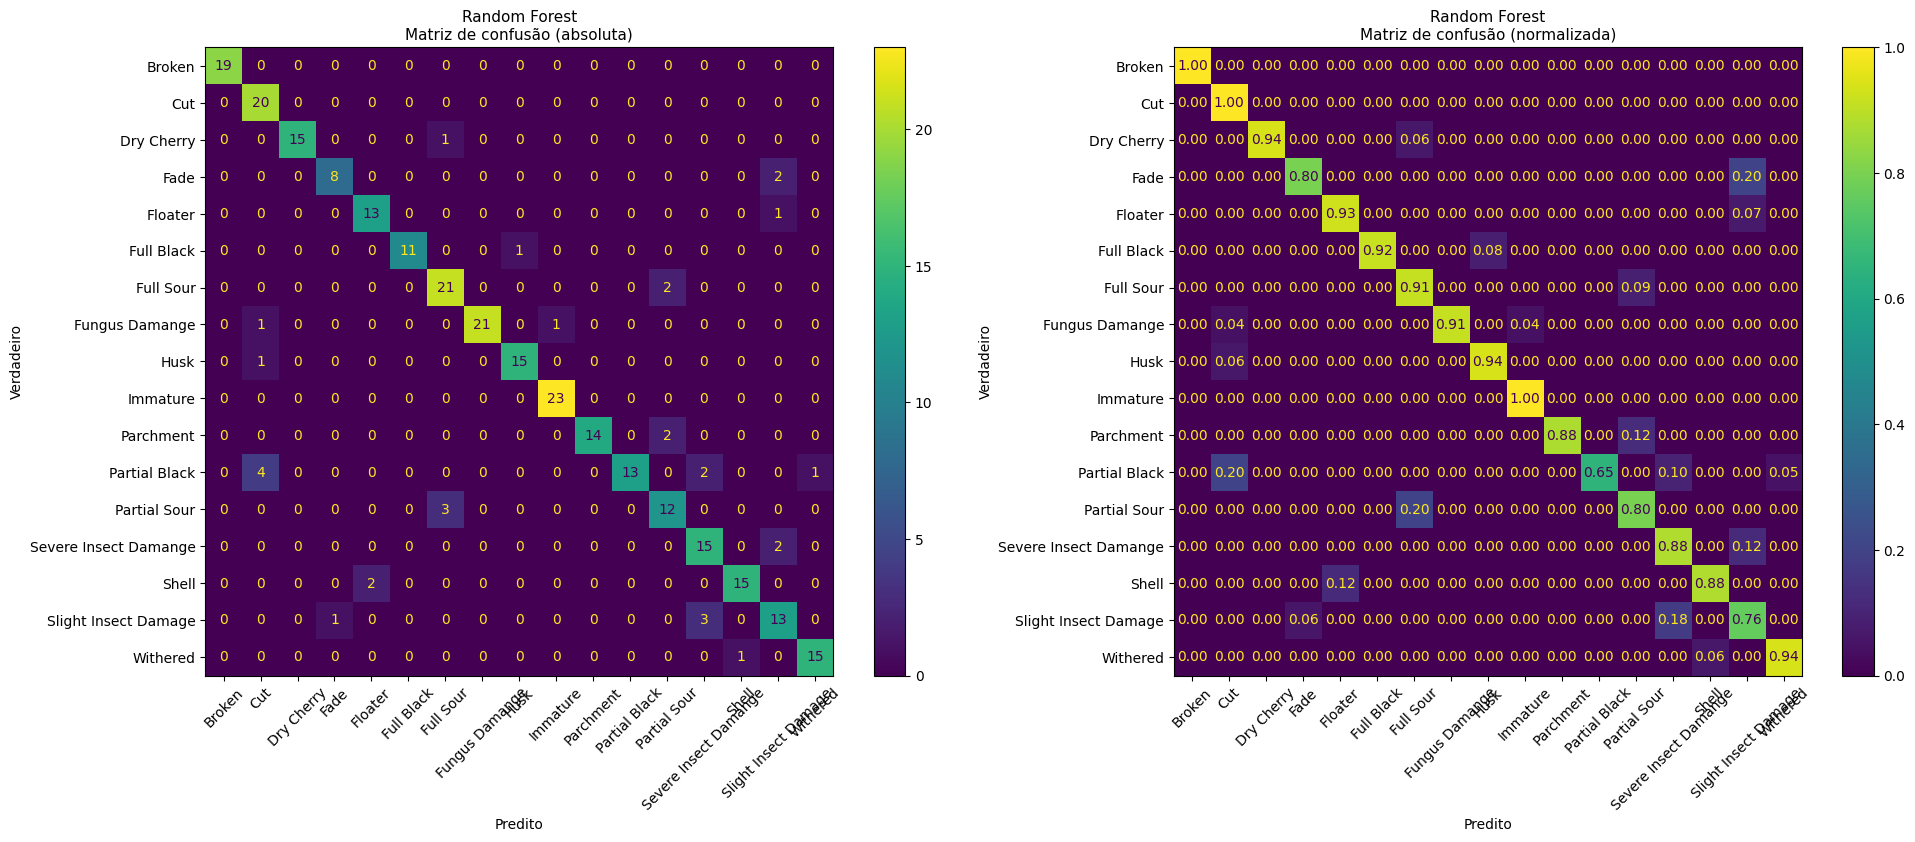

Matriz de confusão salva em ..\outputs\confusao_Random_Forest.png


In [7]:
def evaluate_model(model, X_test_s, y_test, model_name, label_names, outputs_dir):
    """Avalia modelo no teste e gera métricas + matrizes de confusão."""
    y_pred = model.predict(X_test_s)

    metrics = {
        'Modelo':       model_name,
        'Acurácia':     accuracy_score(y_test, y_pred),
        'Precisão (macro)': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Precisão (micro)': precision_score(y_test, y_pred, average='micro', zero_division=0),
        'Recall (macro)':   recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1 (macro)':       f1_score(y_test, y_pred, average='macro', zero_division=0),
        'F1 (micro)':       f1_score(y_test, y_pred, average='micro', zero_division=0),
    }

    print(f'\n{'='*60}')
    print(f'  {model_name} — Avaliação no conjunto de TESTE')
    print('='*60)
    for k, v in metrics.items():
        if k != 'Modelo':
            print(f'  {k:<25}: {v:.4f}')

    print('\nRelatório de classificação:')
    used_labels = sorted(y_test.unique())
    used_names  = [label_names[i] for i in used_labels]
    print(classification_report(y_test, y_pred,
                                 labels=used_labels,
                                 target_names=used_names,
                                 zero_division=0))

    # Matriz de confusão absoluta
    cm = confusion_matrix(y_test, y_pred, labels=used_labels)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    for ax, normalize, title in zip(
        axes,
        [None, 'true'],
        ['Matriz de confusão (absoluta)', 'Matriz de confusão (normalizada)']
    ):
        disp = ConfusionMatrixDisplay(
            confusion_matrix(y_test, y_pred, labels=used_labels, normalize=normalize),
            display_labels=used_names
        )
        disp.plot(ax=ax, colorbar=True, xticks_rotation=45,
                  values_format='.0f' if normalize is None else '.2f')
        ax.set_title(f'{model_name}\n{title}', fontsize=11)
        ax.set_xlabel('Predito')
        ax.set_ylabel('Verdadeiro')

    plt.tight_layout()
    fname = outputs_dir / f'confusao_{model_name.replace(" ", "_")}.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Matriz de confusão salva em {fname}')

    return metrics, y_pred

# Avalia Random Forest
metrics_rf, pred_rf = evaluate_model(
    best_rf, X_test_s, y_test, 'Random Forest', label_names, OUTPUTS_DIR
)


  SVM RBF — Avaliação no conjunto de TESTE
  Acurácia                 : 0.8844
  Precisão (macro)         : 0.8956
  Precisão (micro)         : 0.8844
  Recall (macro)           : 0.8741
  F1 (macro)               : 0.8787
  F1 (micro)               : 0.8844

Relatório de classificação:
                       precision    recall  f1-score   support

               Broken       0.95      1.00      0.97        19
                  Cut       0.83      1.00      0.91        20
           Dry Cherry       0.94      1.00      0.97        16
                 Fade       0.83      0.50      0.62        10
              Floater       1.00      0.93      0.96        14
           Full Black       1.00      1.00      1.00        12
            Full Sour       0.85      0.96      0.90        23
       Fungus Damange       0.95      0.83      0.88        23
                 Husk       1.00      0.94      0.97        16
             Immature       0.79      1.00      0.88        23
            Parch

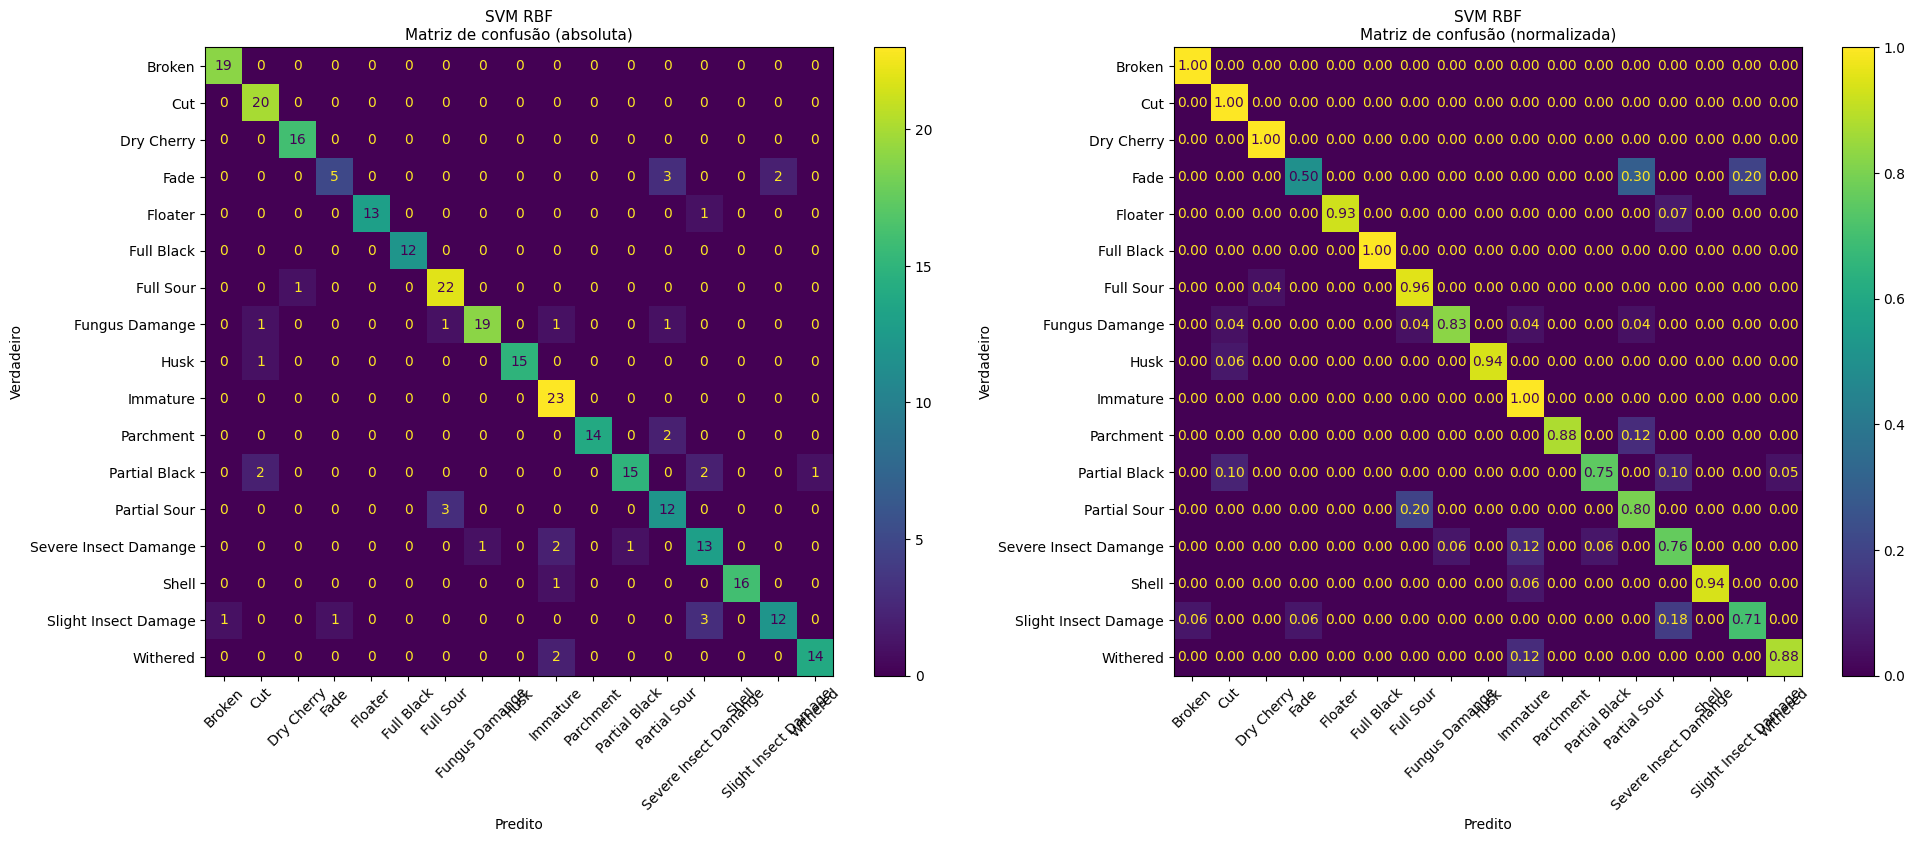

Matriz de confusão salva em ..\outputs\confusao_SVM_RBF.png


In [8]:
# Avalia SVM
metrics_svm, pred_svm = evaluate_model(
    best_svm, X_test_s, y_test, 'SVM RBF', label_names, OUTPUTS_DIR
)

## 7. Tabela comparativa final


              TABELA COMPARATIVA — CONJUNTO DE TESTE


,Acurácia,Precisão (macro),Precisão (micro),Recall (macro),F1 (macro),F1 (micro)
Modelo,,,,,,
Random Forest,0.8946,0.9034,0.8946,0.8905,0.8926,0.8946
SVM RBF,0.8844,0.8956,0.8844,0.8741,0.8787,0.8844


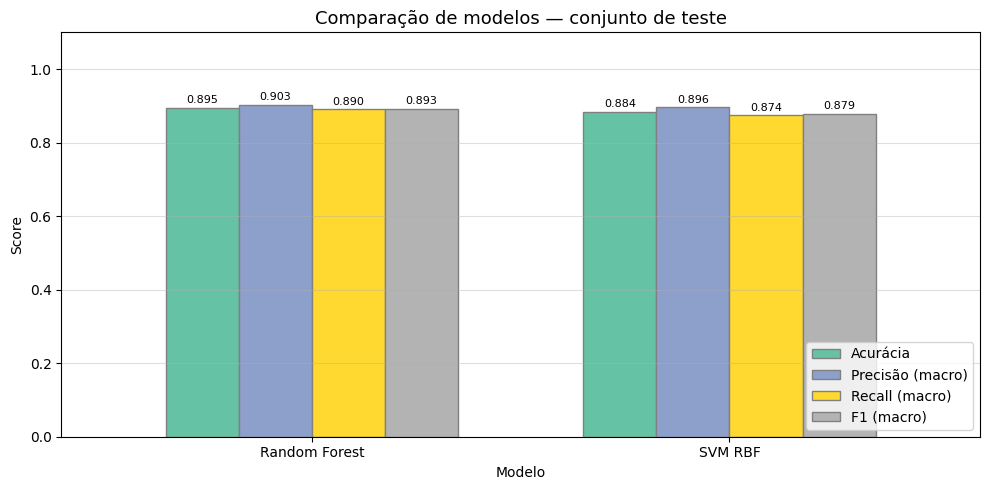

In [9]:
comparison_df = pd.DataFrame([metrics_rf, metrics_svm]).set_index('Modelo')
comparison_df = comparison_df.round(4)

print('\n' + '='*70)
print('              TABELA COMPARATIVA — CONJUNTO DE TESTE')
print('='*70)
display(comparison_df)

# Salva como CSV
comparison_df.to_csv(OUTPUTS_DIR / 'comparacao_modelos.csv')

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 5))
metrics_cols = ['Acurácia', 'Precisão (macro)', 'Recall (macro)', 'F1 (macro)']
comparison_df[metrics_cols].plot(kind='bar', ax=ax, rot=0, colormap='Set2',
                                  edgecolor='grey', width=0.7)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparação de modelos — conjunto de teste', fontsize=13)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.4)
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / 'comparacao_modelos.png', dpi=150)
plt.show()

## 8. Análise de erros

Seleciona 5–10 imagens onde o melhor modelo errou e exibe a imagem original com a predição vs. verdade para levantamento de hipóteses.

In [10]:
# Identifica o melhor modelo
best_model_name = comparison_df['F1 (macro)'].idxmax()
best_pred       = pred_rf if best_model_name == 'Random Forest' else pred_svm
best_model      = best_rf if best_model_name == 'Random Forest' else best_svm
print(f'Melhor modelo: {best_model_name}')

# Recupera os paths das imagens de teste
records_df = pd.read_csv(OUTPUTS_DIR / 'image_records.csv')
valid_df   = records_df[records_df['mask_ok']].copy().reset_index(drop=True)

# Reconstrói o índice do split
np.random.seed(RANDOM_STATE)
idx_all = np.arange(len(valid_df))

# Repete os splits com a mesma semente para recuperar os índices de teste
idx_temp, idx_test = train_test_split(idx_all, test_size=0.15,
                                       stratify=valid_df['label_index'],
                                       random_state=RANDOM_STATE)
val_ratio = 0.15 / 0.85
idx_train, idx_val = train_test_split(idx_temp, test_size=val_ratio,
                                       stratify=valid_df.iloc[idx_temp]['label_index'],
                                       random_state=RANDOM_STATE)

test_paths  = valid_df.iloc[idx_test]['path'].values
test_labels = valid_df.iloc[idx_test]['label_index'].values

Melhor modelo: Random Forest


Total de erros: 31 de 294 (10.5%)


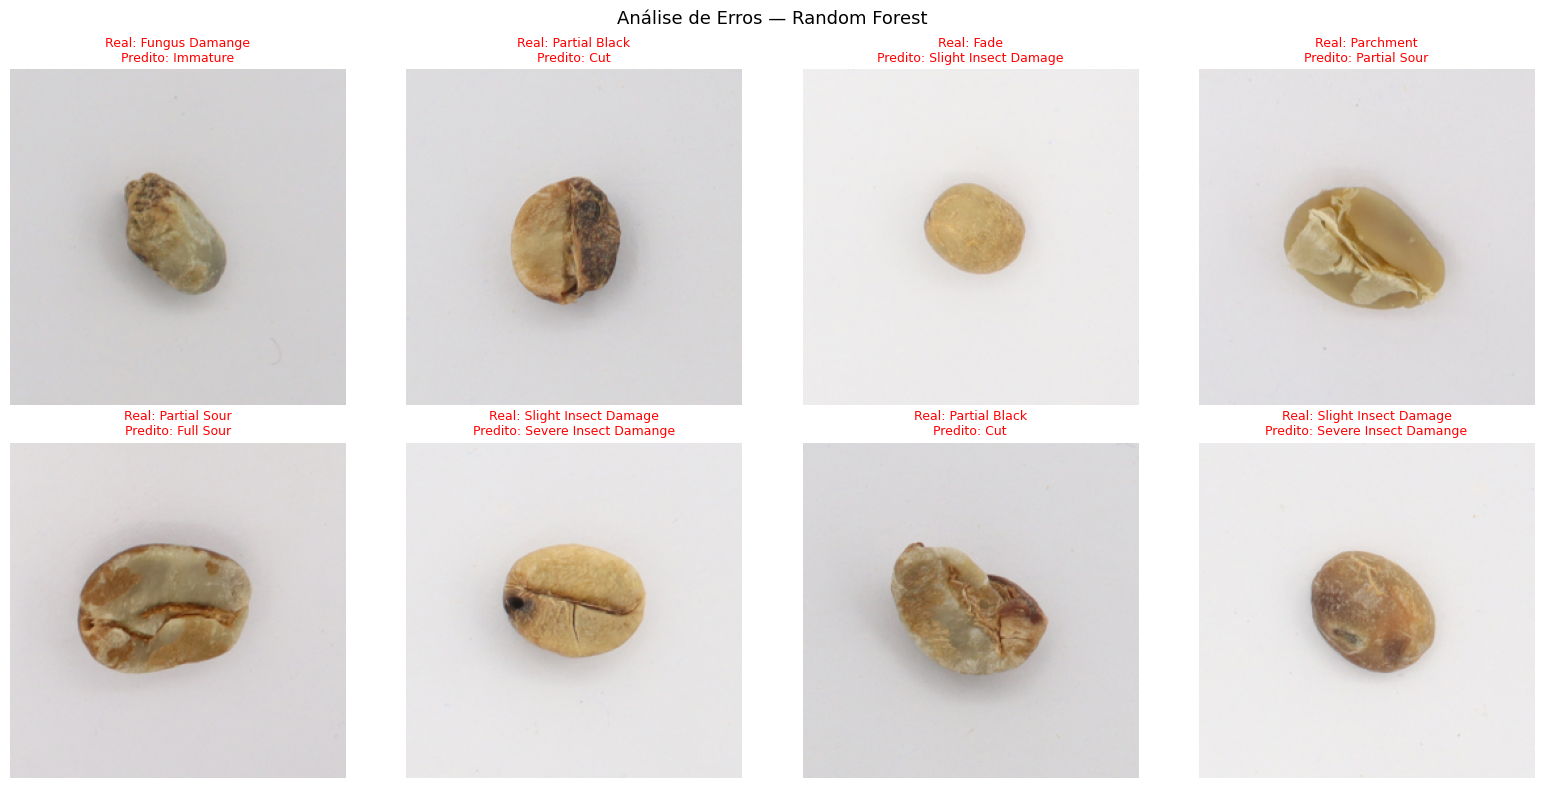


Tabela de hipóteses para os erros:


,real,predito,hipotese
0,Fungus Damange,Immature,Possível sobreposição de features ou segmentaç...
1,Partial Black,Cut,Variação de cor entre defeitos de fermentação
2,Fade,Slight Insect Damage,"Área de dano de inseto sutil, difícil distinçã..."
3,Parchment,Partial Sour,Possível sobreposição de features ou segmentaç...
4,Partial Sour,Full Sour,Variação de cor entre defeitos de fermentação
5,Slight Insect Damage,Severe Insect Damange,"Área de dano de inseto sutil, difícil distinçã..."
6,Partial Black,Cut,Variação de cor entre defeitos de fermentação
7,Slight Insect Damage,Severe Insect Damange,"Área de dano de inseto sutil, difícil distinçã..."


In [11]:
# Identifica erros
error_mask  = best_pred != y_test.values
error_paths = test_paths[error_mask]
error_true  = y_test.values[error_mask]
error_pred  = best_pred[error_mask]

print(f'Total de erros: {error_mask.sum()} de {len(y_test)} ({100*error_mask.mean():.1f}%)')

# Seleciona até 8 erros aleatórios
n_show = min(8, len(error_paths))
rng = np.random.default_rng(RANDOM_STATE)
sel = rng.choice(len(error_paths), size=n_show, replace=False)

CHOSEN_METHOD = CONFIG['chosen_method']
TARGET_SIZE   = tuple(CONFIG['target_size'])

def load_image(path, target_size=(256, 256)):
    img = cv2.imread(str(path))
    if img is None:
        return None
    return cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)

n_cols = 4
n_rows = (n_show + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4))
axes = axes.flat

hypotheses = []
for i, idx in enumerate(sel):
    path      = error_paths[idx]
    true_cls  = label_names[error_true[idx]]
    pred_cls  = label_names[error_pred[idx]]

    bgr = load_image(path, TARGET_SIZE)
    if bgr is not None:
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        axes[i].imshow(rgb)
    axes[i].set_title(f'Real: {true_cls}\nPredito: {pred_cls}',
                       fontsize=9, color='red' if true_cls != pred_cls else 'green')
    axes[i].axis('off')

    # Hipótese automática
    hyp = []
    if true_cls in pred_cls or pred_cls in true_cls:
        hyp.append('Defeitos visualmente similares (ex: Partial vs Full)')
    if 'Insect' in true_cls or 'Insect' in pred_cls:
        hyp.append('Área de dano de inseto sutil, difícil distinção leve/grave')
    if 'Sour' in true_cls or 'Black' in true_cls:
        hyp.append('Variação de cor entre defeitos de fermentação')
    if not hyp:
        hyp.append('Possível sobreposição de features ou segmentação imperfeita')
    hypotheses.append({'path': path, 'real': true_cls, 'predito': pred_cls, 'hipotese': '; '.join(hyp)})

for ax in list(axes)[n_show:]:
    ax.set_visible(False)

plt.suptitle(f'Análise de Erros — {best_model_name}', fontsize=13)
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / 'analise_erros.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTabela de hipóteses para os erros:')
hyp_df = pd.DataFrame(hypotheses)
display(hyp_df[['real', 'predito', 'hipotese']])

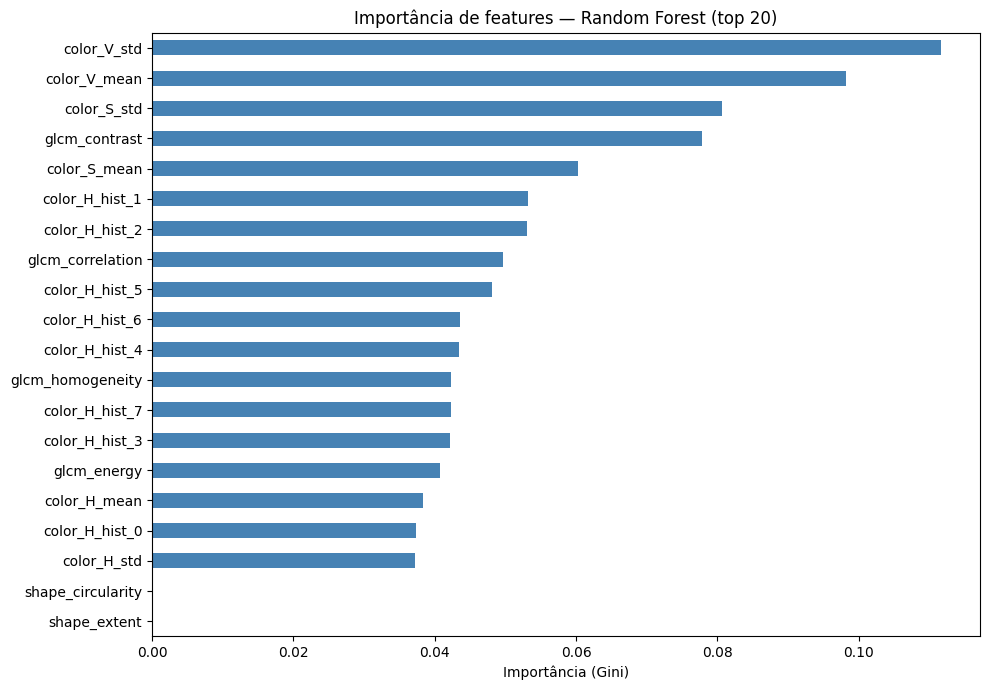

Figura salva: outputs/feature_importance_rf.png


In [12]:
# ── Importância de features (Random Forest) ───────────────────────────────────
if hasattr(best_rf, 'feature_importances_'):
    fi = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 7))
    fi.head(20)[::-1].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Importância de features — Random Forest (top 20)', fontsize=12)
    ax.set_xlabel('Importância (Gini)')
    plt.tight_layout()
    fig.savefig(OUTPUTS_DIR / 'feature_importance_rf.png', dpi=150)
    plt.show()
    print('Figura salva: outputs/feature_importance_rf.png')

In [13]:
print('\n' + '='*60)
print('  RESUMO FINAL')
print('='*60)
print(comparison_df[['Acurácia', 'F1 (macro)']].to_string())
print(f'\n✅ Melhor modelo: {best_model_name}')
print(f'   F1-macro (teste): {comparison_df.loc[best_model_name, "F1 (macro)"]:.4f}')
print(f'   Acurácia (teste): {comparison_df.loc[best_model_name, "Acurácia"]:.4f}')
print(f'\nArquivos salvos em outputs/:')
print('  - comparacao_modelos.csv / .png')
print('  - confusao_Random_Forest.png')
print('  - confusao_SVM_RBF.png')
print('  - analise_erros.png')
print('  - feature_importance_rf.png')


  RESUMO FINAL
               Acurácia  F1 (macro)
Modelo                             
Random Forest    0.8946      0.8926
SVM RBF          0.8844      0.8787

✅ Melhor modelo: Random Forest
   F1-macro (teste): 0.8926
   Acurácia (teste): 0.8946

Arquivos salvos em outputs/:
  - comparacao_modelos.csv / .png
  - confusao_Random_Forest.png
  - confusao_SVM_RBF.png
  - analise_erros.png
  - feature_importance_rf.png
